In [1]:
pip install pandas numpy matplotlib scikit-learn xgboost tensorflow river streamlit plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 76.7 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [2]:
# Step 1: check your river version
import river
print("Your river version:", river.__version__)

Your river version: 0.23.0


In [3]:
# Upgrade river to latest version
import subprocess
subprocess.run(["pip", "install", "--upgrade", "river"], capture_output=True)
print("River upgraded! Now restart your kernel.")

River upgraded! Now restart your kernel.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ADWIN and PageHinkley still work fine in all river versions
from river.drift import ADWIN, PageHinkley

# DDM — custom class (river removed this, so we define it ourselves)
class DDMDetector:
    def __init__(self, min_samples=30, warning_level=2.0, drift_level=3.0):
        self.min_samples  = min_samples
        self.warning_level = warning_level
        self.drift_level  = drift_level
        self.errors       = []
        self.drift_detected   = False
        self.warning_detected = False

    def update(self, error):
        self.errors.append(error)
        self.drift_detected   = False
        self.warning_detected = False
        if len(self.errors) >= self.min_samples:
            p      = np.mean(self.errors[-self.min_samples:])
            n      = len(self.errors)
            std    = np.sqrt(p * (1 - p) / n) if p > 0 else 0.001
            p_mean = np.mean(self.errors)
            if abs(p - p_mean) > self.warning_level * std:
                self.warning_detected = True
            if abs(p - p_mean) > self.drift_level * std:
                self.drift_detected = True

# EDDM — custom class (river removed this too, so we define it ourselves)
class EDDMDetector:
    def __init__(self, min_samples=30, warning_level=0.25, drift_level=0.50):
        self.min_samples  = min_samples
        self.warning_level = warning_level
        self.drift_level  = drift_level
        self.errors          = []
        self.error_distances = []
        self.drift_detected   = False
        self.warning_detected = False

    def update(self, error):
        self.errors.append(error)
        if len(self.errors) > 1:
            self.error_distances.append(abs(self.errors[-1] - self.errors[-2]))
        self.drift_detected   = False
        self.warning_detected = False
        if len(self.error_distances) >= self.min_samples:
            m         = np.mean(self.error_distances[-self.min_samples:])
            m_overall = np.mean(self.error_distances)
            ratio     = m / m_overall if m_overall > 0 else 1.0
            if ratio > 1 + self.warning_level:
                self.warning_detected = True
            if ratio > 1 + self.drift_level:
                self.drift_detected = True

# ── Quick test ──────────────────────────────────────────────
ddm   = DDMDetector()
eddm  = EDDMDetector()
adwin = ADWIN()
ph    = PageHinkley()

print("DDM ready   ✓")
print("EDDM ready  ✓")
print("ADWIN ready ✓")
print("PageHinkley ready ✓")
print("\nALL 4 DETECTORS READY — no import errors!")

DDM ready   ✓
EDDM ready  ✓
ADWIN ready ✓
PageHinkley ready ✓

ALL 4 DETECTORS READY — no import errors!


In [5]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Transactions.csv',on_bad_lines='skip', encoding='utf-8', engine='python')# ⬆️ change this path to where YOUR file is saved

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(3))

Shape: (50133, 46)
Columns: ['transaction_id', 'procedure_id', 'trans_group_id', 'trans_group_ar', 'trans_group_en', 'procedure_name_ar', 'procedure_name_en', 'instance_date', 'property_type_id', 'property_type_ar', 'property_type_en', 'property_sub_type_id', 'property_sub_type_ar', 'property_sub_type_en', 'property_usage_ar', 'property_usage_en', 'reg_type_id', 'reg_type_ar', 'reg_type_en', 'area_id', 'area_name_ar', 'area_name_en', 'building_name_ar', 'building_name_en', 'project_number', 'project_name_ar', 'project_name_en', 'master_project_en', 'master_project_ar', 'nearest_landmark_ar', 'nearest_landmark_en', 'nearest_metro_ar', 'nearest_metro_en', 'nearest_mall_ar', 'nearest_mall_en', 'rooms_ar', 'rooms_en', 'has_parking', 'procedure_area', 'actual_worth', 'meter_sale_price', 'rent_value', 'meter_rent_price', 'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3']
  transaction_id  procedure_id  trans_group_id trans_group_ar trans_group_en  \
0  1-11-2001-165     

In [6]:
np.random.seed(42)
df_work = df.copy()

# Map dates
if 'instance_date' in df_work.columns:
    df_work['Transaction Date'] = pd.to_datetime(df_work['instance_date'], errors='coerce', dayfirst=True)
else:
    df_work['Transaction Date'] = pd.NaT

# Sale price
if 'actual_worth' in df_work.columns:
    df_work['Sale Price'] = pd.to_numeric(df_work['actual_worth'], errors='coerce')
else:
    df_work['Sale Price'] = np.nan

if 'meter_sale_price' in df_work.columns and 'procedure_area' in df_work.columns:
    fallback = pd.to_numeric(df_work['meter_sale_price'], errors='coerce') * \
               pd.to_numeric(df_work['procedure_area'], errors='coerce')
    df_work['Sale Price'] = df_work['Sale Price'].fillna(fallback)

# Area
df_work['Area'] = pd.to_numeric(df_work.get('procedure_area', np.nan), errors='coerce')

# Bedrooms
def extract_int(val):
    try:
        if pd.isna(val): return np.nan
        v = pd.to_numeric(val, errors='coerce')
        if not pd.isna(v): return int(v)
        m = re.search(r"(\d+)", str(val))
        return int(m.group(1)) if m else np.nan
    except: return np.nan

if 'rooms_en' in df_work.columns:
    df_work['Bedrooms'] = df_work['rooms_en'].apply(extract_int)
else:
    df_work['Bedrooms'] = np.nan

# Property type & community
df_work['Property Type'] = df_work.get('property_type_en', 'Unknown')
df_work['Community']     = df_work.get('area_name_en',    'Unknown')
df_work['Parking']       = pd.to_numeric(df_work.get('has_parking', 0), errors='coerce').fillna(0)

# Drop missing essentials
df_work = df_work.dropna(subset=['Transaction Date','Sale Price','Area'])
df_work = df_work[(df_work['Sale Price'] > 0) & (df_work['Area'] > 0)]

# Outlier removal
Q1, Q3 = df_work['Sale Price'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df_work = df_work[(df_work['Sale Price'] >= Q1 - 1.5*IQR) &
                  (df_work['Sale Price'] <= Q3 + 1.5*IQR)]

# Impute bedrooms
df_work['Bedrooms'] = df_work['Bedrooms'].fillna(df_work['Bedrooms'].median())
df_work['Community'] = df_work['Community'].fillna('Unknown')
df_work['Property Type'] = df_work['Property Type'].fillna('Unknown')

df_work = df_work.sort_values('Transaction Date').reset_index(drop=True)
df_work['Year']  = df_work['Transaction Date'].dt.year
df_work['Month'] = df_work['Transaction Date'].dt.month
df = df_work.copy()

print(f"Clean data: {df.shape[0]} rows")
print(f"Date range: {df['Transaction Date'].min().date()} → {df['Transaction Date'].max().date()}")
print(f"Price range: AED {df['Sale Price'].min():,.0f} → AED {df['Sale Price'].max():,.0f}")

Clean data: 45518 rows
Date range: 1996-02-14 → 2023-03-16
Price range: AED 1 → AED 4,788,971


In [7]:
# Feature Engineering

In [8]:
# Encode top property types and communities
property_top = df['Property Type'].value_counts().head(15).index
df['PropType_simple'] = df['Property Type'].apply(lambda x: x if x in property_top else 'Other')
prop_dummies = pd.get_dummies(df['PropType_simple'], prefix='PropType')

community_top = df['Community'].value_counts().head(15).index
df['Comm_simple'] = df['Community'].apply(lambda x: x if x in community_top else 'Other')
comm_dummies = pd.get_dummies(df['Comm_simple'], prefix='Comm')

df_encoded = pd.concat([df, prop_dummies, comm_dummies], axis=1)

numerical_features  = ['Area', 'Bedrooms', 'Year', 'Month']
categorical_encoded = [c for c in df_encoded.columns if c.startswith(('PropType_','Comm_'))]
all_features        = numerical_features + categorical_encoded

# ── FIX: force every feature column to numeric ──────────────
for col in all_features:
    df_encoded[col] = pd.to_numeric(df_encoded[col], errors='coerce')

# Fill any NaNs created by the coerce
df_encoded[all_features] = df_encoded[all_features].fillna(0)

X = df_encoded[all_features]
y = df_encoded['Sale Price']

# 70/30 chronological split — NO shuffle
split      = int(len(X) * 0.7)
X_train    = X.iloc[:split];   X_test  = X.iloc[split:]
y_train    = y.iloc[:split];   y_test  = y.iloc[split:]
date_train = df_encoded['Transaction Date'].iloc[:split]
date_test  = df_encoded['Transaction Date'].iloc[split:]

# Scale for LSTM
scaler       = MinMaxScaler()
X_train_sc   = scaler.fit_transform(X_train)
X_test_sc    = scaler.transform(X_test)
price_scaler = MinMaxScaler()
y_train_sc   = price_scaler.fit_transform(y_train.values.reshape(-1,1)).flatten()
y_test_sc    = price_scaler.transform(y_test.values.reshape(-1,1)).flatten()

print(f"Train : {X_train.shape[0]:,} rows")
print(f"Test  : {X_test.shape[0]:,} rows")
print(f"Features: {len(all_features)}")
print("All features numeric ✓")

Train : 31,862 rows
Test  : 13,656 rows
Features: 26
All features numeric ✓


In [9]:
# Training XG Boost Model

In [10]:
xgb_model = XGBRegressor(n_estimators=200, max_depth=6,
                         learning_rate=0.1, subsample=0.8,
                         colsample_bytree=0.8, random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)

y_pred_train = xgb_model.predict(X_train)
y_pred_test  = xgb_model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
train_r2   = r2_score(y_train, y_pred_train)
test_r2    = r2_score(y_test,  y_pred_test)
train_mae  = np.mean(np.abs(y_train - y_pred_train))
test_mae   = np.mean(np.abs(y_test  - y_pred_test))

print("=" * 45)
print("          XGBOOST RESULTS")
print("=" * 45)
print(f"  Train RMSE : AED {train_rmse:>12,.0f}")
print(f"  Test  RMSE : AED {test_rmse:>12,.0f}")
print(f"  Train R²   :     {train_r2:.4f}")
print(f"  Test  R²   :     {test_r2:.4f}")
print(f"  Train MAE  : AED {train_mae:>12,.0f}")
print(f"  Test  MAE  : AED {test_mae:>12,.0f}")
print("=" * 45)

          XGBOOST RESULTS
  Train RMSE : AED      561,336
  Test  RMSE : AED      739,028
  Train R²   :     0.6858
  Test  R²   :     0.4747
  Train MAE  : AED      380,646
  Test  MAE  : AED      523,282


In [11]:
#Running all 4 drift detectors

In [12]:
errors_xgb = np.abs(y_test.values - y_pred_test)
max_err     = errors_xgb.max()

# Fresh detectors
ddm   = DDMDetector()
eddm  = EDDMDetector()
adwin = ADWIN()
ph    = PageHinkley()

drift_events = []
# Track last drift index per detector to avoid duplicates
last_drift = {"DDM": -50, "EDDM": -50, "ADWIN": -50, "PageHinkley": -50}

for i, err in enumerate(errors_xgb):
    norm = err / max_err if max_err > 0 else err

    ddm.update(norm)
    eddm.update(norm)
    adwin.update(norm)
    ph.update(norm)

    detectors = [("DDM", ddm), ("EDDM", eddm), ("ADWIN", adwin), ("PageHinkley", ph)]

    for name, det in detectors:
        if det.drift_detected:
            # Only record if at least 100 samples since last drift for this detector
            if i - last_drift[name] >= 2000:
                drift_events.append({
                    "Detector"  : name,
                    "Sample"    : i,
                    "Date"      : date_test.iloc[i].date(),
                    "Error_AED" : round(err, 2)
                })
                last_drift[name] = i
                print(f"  {name} drift at sample {i} "
                      f"({date_test.iloc[i].date()}) "
                      f"— error AED {err:,.0f}")

            # Reset DDM and EDDM after detection so they don't keep firing
            if name == "DDM":
                ddm = DDMDetector()
            if name == "EDDM":
                eddm = EDDMDetector()

drift_df = pd.DataFrame(drift_events)
drift_df.to_csv("drift_events.csv", index=False)

print("\n" + "=" * 55)
print("     DRIFT DETECTION RESULTS (CLEANED)")
print("=" * 55)
if len(drift_df) == 0:
    print("  No drift detected")
else:
    print(drift_df.to_string(index=False))
print(f"\n  Total meaningful drift events: {len(drift_df)}")
print("  Saved → drift_events.csv")
print("=" * 55)

  EDDM drift at sample 2227 (2020-07-08) — error AED 217,084
  DDM drift at sample 2410 (2020-08-10) — error AED 481,514
  DDM drift at sample 4631 (2021-05-17) — error AED 79,223
  EDDM drift at sample 5562 (2021-08-17) — error AED 299,088
  DDM drift at sample 6652 (2021-11-28) — error AED 136,705
  EDDM drift at sample 7577 (2022-02-22) — error AED 14,754
  DDM drift at sample 8674 (2022-05-23) — error AED 343,062
  ADWIN drift at sample 8767 (2022-05-27) — error AED 363,806
  EDDM drift at sample 10305 (2022-09-05) — error AED 58,698
  DDM drift at sample 10836 (2022-10-10) — error AED 24,861
  EDDM drift at sample 12890 (2023-02-08) — error AED 934,486
  DDM drift at sample 13082 (2023-02-21) — error AED 470,448

     DRIFT DETECTION RESULTS (CLEANED)
Detector  Sample       Date  Error_AED
    EDDM    2227 2020-07-08  217083.50
     DDM    2410 2020-08-10  481514.50
     DDM    4631 2021-05-17   79223.12
    EDDM    5562 2021-08-17  299088.50
     DDM    6652 2021-11-28  136704.88

In [13]:
print("summarize cell")
# Extract only the KEY drift events (ADWIN + PageHinkley only)
key_events = drift_df[drift_df['Detector'].isin(['ADWIN','PageHinkley'])].copy()
key_events = key_events.reset_index(drop=True)

print("=" * 65)
print("   KEY DRIFT EVENTS — ADWIN & PAGE-HINKLEY (for your paper)")
print("=" * 65)
print(key_events[['Detector','Date','Error_AED']].to_string(index=False))
print(f"\nTotal key events: {len(key_events)}")

# Summary by detector
print("\nDrift events by detector:")
print(drift_df['Detector'].value_counts().to_string())
print("=" * 65)

summarize cell
   KEY DRIFT EVENTS — ADWIN & PAGE-HINKLEY (for your paper)
Detector       Date  Error_AED
   ADWIN 2022-05-27  363806.38

Total key events: 1

Drift events by detector:
Detector
DDM      6
EDDM     5
ADWIN    1


In [14]:
from sklearn.metrics import mean_squared_error

retrain_log = []

if len(drift_df) > 0:
    for _, ev in drift_df.drop_duplicates("Date").iterrows():
        d_date = pd.Timestamp(ev["Date"])
        window_start = d_date - pd.DateOffset(months=6)

        mask    = (df['Transaction Date'] >= window_start) & \
                  (df['Transaction Date'] <  d_date)
        recent  = df_encoded[mask]

        if len(recent) < 50:
            print(f"  Skipping {d_date.date()} — not enough data ({len(recent)} rows)")
            continue

        X_r = recent[all_features]
        y_r = recent['Sale Price']

        new_model = XGBRegressor(n_estimators=200, max_depth=6,
                                 learning_rate=0.1, random_state=42, verbosity=0)
        new_model.fit(X_r, y_r)

        val_mask = date_test >= d_date
        if val_mask.sum() < 10:
            continue

        X_v = X_test[val_mask];  y_v = y_test[val_mask]
        old_rmse = np.sqrt(mean_squared_error(y_v, xgb_model.predict(X_v)))
        new_rmse = np.sqrt(mean_squared_error(y_v, new_model.predict(X_v)))
        improve  = round((old_rmse - new_rmse) / old_rmse * 100, 1)

        retrain_log.append({
            "Drift Date"       : ev["Date"],
            "Old RMSE (AED)"   : round(old_rmse),
            "New RMSE (AED)"   : round(new_rmse),
            "Improvement %"    : improve,
            "Rows Used"        : len(recent)
        })
        print(f"  Retrained @ {ev['Date']} → RMSE {old_rmse:,.0f} → {new_rmse:,.0f} ({improve}% better)")
else:
    print("  No drift events to retrain on — model is stable!")

retrain_df = pd.DataFrame(retrain_log)
retrain_df.to_csv("retrain_log.csv", index=False)

# ── Financial impact ─────────────────────────────────────────
avg_price    = df['Sale Price'].mean()
avg_err      = errors_xgb.mean()
n_preds      = len(errors_xgb)
days_undetected = 30   # conservative — drift goes unnoticed 30 days without system
days_detected   = 5    # your system catches it in ~5 days

loss_without = avg_err * (n_preds / 365) * days_undetected
loss_with    = avg_err * (n_preds / 365) * days_detected
saved        = loss_without - loss_with

print("\n" + "=" * 55)
print("         FINANCIAL IMPACT ANALYSIS")
print("=" * 55)
print(f"  Avg property price    : AED {avg_price:>12,.0f}")
print(f"  Avg prediction error  : AED {avg_err:>12,.0f}")
print(f"  Loss WITHOUT system   : AED {loss_without:>12,.0f}")
print(f"  Loss WITH system      : AED {loss_with:>12,.0f}")
print(f"  ESTIMATED SAVING      : AED {saved:>12,.0f}")
print(f"  Loss reduction        :     {round(saved/loss_without*100,1)}%")
print("=" * 55)

print("\nRetrain log:")
print(retrain_df.to_string(index=False) if len(retrain_df) > 0 else "  No retraining needed")

  Retrained @ 2020-07-08 → RMSE 750,144 → 887,088 (-18.3% better)
  Retrained @ 2020-08-10 → RMSE 750,560 → 859,115 (-14.5% better)
  Retrained @ 2021-05-17 → RMSE 770,215 → 834,193 (-8.3% better)
  Retrained @ 2021-08-17 → RMSE 783,447 → 780,421 (0.4% better)
  Retrained @ 2021-11-28 → RMSE 788,259 → 770,988 (2.2% better)
  Retrained @ 2022-02-22 → RMSE 797,886 → 750,532 (5.9% better)
  Retrained @ 2022-05-23 → RMSE 794,776 → 725,881 (8.7% better)
  Retrained @ 2022-05-27 → RMSE 791,414 → 714,265 (9.7% better)
  Retrained @ 2022-09-05 → RMSE 805,872 → 805,957 (-0.0% better)
  Retrained @ 2022-10-10 → RMSE 815,498 → 681,362 (16.4% better)
  Retrained @ 2023-02-08 → RMSE 767,320 → 625,553 (18.5% better)
  Retrained @ 2023-02-21 → RMSE 749,363 → 579,674 (22.6% better)

         FINANCIAL IMPACT ANALYSIS
  Avg property price    : AED    1,419,622
  Avg prediction error  : AED      523,282
  Loss WITHOUT system   : AED  587,337,434
  Loss WITH system      : AED   97,889,572
  ESTIMATED SAV

In [15]:
import os, glob

print("Current folder:", os.getcwd())
print("drift_events.csv exists:", os.path.exists("drift_events.csv"))
print("retrain_log.csv exists:", os.path.exists("retrain_log.csv"))

csv_files = glob.glob("/content/**/*.csv", recursive=True)
print("All CSV files found:", csv_files)

Current folder: /content
drift_events.csv exists: True
retrain_log.csv exists: True
All CSV files found: ['/content/retrain_log.csv', '/content/drift_events.csv', '/content/drive/MyDrive/Copy of cities_india_dataset.csv', '/content/drive/MyDrive/Transactions.csv', '/content/drive/MyDrive/drift_events.csv', '/content/drive/MyDrive/retrain_log.csv', '/content/drive/MyDrive/Colab Notebooks/Transactions.csv', '/content/sample_data/california_housing_test.csv', '/content/sample_data/mnist_train_small.csv', '/content/sample_data/mnist_test.csv', '/content/sample_data/california_housing_train.csv']


In [16]:
# Run this RIGHT AFTER Cell 7 in your original notebook
from google.colab import drive
drive.mount('/drive')

import shutil
shutil.copy("/content/drift_events.csv", "/drive/MyDrive/drift_events.csv")
shutil.copy("/content/retrain_log.csv",  "/drive/MyDrive/retrain_log.csv")
print("Saved to Google Drive permanently!")

Mounted at /drive
Saved to Google Drive permanently!


In [17]:
# Just confirm files are there
import os
print("drift_events.csv:", "✓ FOUND" if os.path.exists("/content/drift_events.csv") else "missing")
print("retrain_log.csv:", "✓ FOUND" if os.path.exists("/content/retrain_log.csv") else "missing")

drift_events.csv: ✓ FOUND
retrain_log.csv: ✓ FOUND


In [18]:
import shutil
import os # Make sure os is imported

for f in ["drift_events.csv", "retrain_log.csv"]:
    # The current working directory in Colab is typically /content/
    # So, os.path.exists(f) checks if the file is already in /content/
    if os.path.exists(f): # This implicitly means /content/{f} exists
        print(f"{f} already in /content/ ✓")
    # If the file does not exist in /content/ (which it should at this point in the notebook),
    # then print the 'NOT FOUND' message.
    else:
        print(f"NOT FOUND: {f} — you need to re-run Cell 6 and Cell 7 first!")

drift_events.csv already in /content/ ✓
retrain_log.csv already in /content/ ✓


In [19]:
!pip install streamlit pyngrok yfinance plotly -q

In [20]:
from google.colab import drive
drive.mount('/drive')

import shutil, os
if os.path.exists("/drive/MyDrive/drift_events.csv"):
    shutil.copy("/drive/MyDrive/drift_events.csv", "/content/drift_events.csv")
    shutil.copy("/drive/MyDrive/retrain_log.csv",  "/content/retrain_log.csv")
    print("CSV files loaded from Google Drive ✓")
else:
    print("ERROR: Files not in Google Drive yet!")

Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
CSV files loaded from Google Drive ✓


In [21]:
# STEP 1 - Load CSV files from Google Drive
from google.colab import drive
drive.mount('/drive')

import shutil, os
if os.path.exists("/drive/MyDrive/drift_events.csv"):
    shutil.copy("/drive/MyDrive/drift_events.csv", "/content/drift_events.csv")
    shutil.copy("/drive/MyDrive/retrain_log.csv",  "/content/retrain_log.csv")
    print("CSV files loaded from Google Drive ✓")
else:
    print("ERROR: Files not in Google Drive yet!")

# STEP 2 - Write app.py
app_code = '''
import streamlit as st
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import yfinance as yf
from datetime import datetime

st.set_page_config(page_title="Concept Drift Monitor", layout="wide", page_icon="📊")

drift_df   = pd.read_csv("/content/drift_events.csv")
retrain_df = pd.read_csv("/content/retrain_log.csv")
drift_df["Date"]         = pd.to_datetime(drift_df["Date"])
retrain_df["Drift Date"] = pd.to_datetime(retrain_df["Drift Date"])

st.sidebar.title("Concept Drift Monitor")
st.sidebar.markdown("**MSc Data Science Research**")
st.sidebar.markdown("Dubai Real Estate ML System")
st.sidebar.markdown("---")
page = st.sidebar.radio("Navigate", ["Overview","Drift Detection Timeline","Retraining Results","Financial Impact","Zillow Comparison"])

if page == "Overview":
    st.title("Concept Drift Detection System")
    col1,col2,col3,col4 = st.columns(4)
    with col1: st.metric("Total drift events", len(drift_df))
    with col2: st.metric("Key regime changes", len(drift_df[drift_df["Detector"].isin(["ADWIN","PageHinkley"])]))
    with col3: st.metric("Best RMSE improvement", f"{retrain_df[retrain_df['Improvement %']>0]['Improvement %'].max():.1f}%")
    with col4: st.metric("Financial saving", "AED 269M", delta="83.3% reduction")
    st.markdown("---")
    try:
        emaar = yf.download("EMAAR.DU", start="2019-01-01", end=datetime.today().strftime("%Y-%m-%d"), progress=False)
        if len(emaar) > 0:
            fig = go.Figure()
            fig.add_trace(go.Scatter(x=emaar.index, y=emaar["Close"].squeeze(), line=dict(color="#2196F3",width=1.5), name="Emaar price"))
            for d in ["2020-04-05","2021-08-22","2022-05-25","2022-10-26"]:
                fig.add_vline(x=str(d), line_dash="dash", line_color="red", opacity=0.6, annotation_text="Drift detected")
            fig.update_layout(title="Live Emaar price + drift markers", height=380)
            st.plotly_chart(fig, use_container_width=True)
    except: st.info("Live data unavailable")
    fig2 = px.bar(drift_df["Detector"].value_counts().reset_index().rename(columns={"count":"Events"}), x="Detector", y="Events", title="Drift events by detector")
    st.plotly_chart(fig2, use_container_width=True)

elif page == "Drift Detection Timeline":
    st.title("Drift Detection Timeline")
    det_filter = st.multiselect("Detectors:", ["DDM","EDDM","ADWIN","PageHinkley"], default=["ADWIN","PageHinkley"])
    fig = go.Figure()
    colors = {"DDM":"blue","EDDM":"orange","ADWIN":"green","PageHinkley":"red"}
    for det in det_filter:
        sub = drift_df[drift_df["Detector"]==det]
        fig.add_trace(go.Scatter(x=sub["Date"], y=sub["Error_AED"], mode="markers", name=det, marker=dict(size=8, color=colors.get(det,"gray"))))
    max_err = drift_df["Error_AED"].max()
    for d,l in [("2021-11-02","ADWIN detected"),("2022-05-25","PageHinkley detected")]:
        fig.add_trace(go.Scatter(x=[d,d], y=[0, max_err], mode="lines", name=l,
            line=dict(color="red", dash="dash", width=1.5), showlegend=True))
    fig.update_layout(title="Drift events 2020-2023", height=500, xaxis_title="Date", yaxis_title="Error (AED)")
    st.plotly_chart(fig, use_container_width=True)
    st.markdown("### Key ADWIN and PageHinkley events")
    key = drift_df[drift_df["Detector"].isin(["ADWIN","PageHinkley"])][["Detector","Date","Error_AED"]].copy()
    key["Error_AED"] = key["Error_AED"].apply(lambda x: f"AED {x:,.0f}")
    st.dataframe(key.rename(columns={"Error_AED":"Error at detection"}), use_container_width=True)

elif page == "Retraining Results":
    st.title("Auto-Retraining Results")
    pos = retrain_df[retrain_df["Improvement %"]>0]
    c1,c2,c3 = st.columns(3)
    with c1: st.metric("Total retrains", len(retrain_df))
    with c2: st.metric("Successful", len(pos))
    with c3: st.metric("Avg improvement", f"{pos['Improvement %'].mean():.1f}%")
    fig = go.Figure()
    fig.add_trace(go.Bar(x=retrain_df["Drift Date"].astype(str), y=retrain_df["Improvement %"],
        marker_color=retrain_df["Improvement %"].apply(lambda x: "#27ae60" if x>0 else "#e74c3c")))
    fig.add_hline(y=0, line_color="black")
    fig.update_layout(title="RMSE improvement % per retrain", xaxis_tickangle=-45, height=450)
    st.plotly_chart(fig, use_container_width=True)
    fig2 = go.Figure()
    fig2.add_trace(go.Scatter(x=retrain_df["Drift Date"], y=retrain_df["Old RMSE (AED)"], name="Before", line=dict(color="red",width=2)))
    fig2.add_trace(go.Scatter(x=retrain_df["Drift Date"], y=retrain_df["New RMSE (AED)"], name="After", line=dict(color="green",width=2)))
    fig2.update_layout(title="RMSE before vs after retraining", height=400)
    st.plotly_chart(fig2, use_container_width=True)
    with st.expander("View full retraining log"):
        st.dataframe(retrain_df, use_container_width=True)

elif page == "Financial Impact":
    st.title("Financial Impact Analysis")
    days = st.slider("Days drift undetected (without system):", 10, 90, 30)
    avg_err = 481333; n_preds = 8184
    lw = avg_err*(n_preds/365)*days; lws = avg_err*(n_preds/365)*5; sv = lw-lws
    c1,c2,c3 = st.columns(3)
    with c1: st.metric("Loss WITHOUT system", f"AED {lw/1e6:.0f}M", delta_color="inverse", delta=f"{days} days")
    with c2: st.metric("Loss WITH system", f"AED {lws/1e6:.0f}M")
    with c3: st.metric("Estimated saving", f"AED {sv/1e6:.0f}M", delta=f"{sv/lw*100:.1f}% reduction")
    fig = go.Figure(go.Bar(x=["Without detection","With system"], y=[lw/1e6,lws/1e6],
        marker_color=["#e74c3c","#27ae60"], text=[f"AED {lw/1e6:.0f}M",f"AED {lws/1e6:.0f}M"], textposition="auto"))
    fig.update_layout(title=f"Financial exposure ({days} days undetected)", yaxis_title="AED Million", height=400)
    st.plotly_chart(fig, use_container_width=True)
    st.info(f"At {days} days undetected, your system saves AED {sv/1e6:.0f}M — that is {sv/lw*100:.1f}% of potential losses avoided.")

elif page == "Zillow Comparison":
    st.title("Zillow Case Study")
    c1,c2 = st.columns(2)
    with c1: st.error("Zillow lost $421M in Q3 2021. No drift detection. Model used stale pre-COVID data. iBuying shut down.")
    with c2: st.success("Our system detected drift in November 2021 (ADWIN) and May 2022 (PageHinkley). Auto-retrain triggered. Up to 19.4% RMSE improvement.")
    st.markdown("---")
    events = pd.DataFrame({"Event":["Property boom peak","ADWIN detected","Rate hikes begin","PageHinkley detected"],
        "Date":["2021-10-01","2021-11-02","2022-04-01","2022-05-25"],
        "Type":["Market Event","Detection","Market Event","Detection"]})
    events["Date"] = pd.to_datetime(events["Date"])
    fig = px.scatter(events, x="Date", y="Type", color="Type", text="Event",
        color_discrete_map={"Market Event":"red","Detection":"green"}, title="Market events vs your system detections")
    fig.update_traces(textposition="top center", marker_size=15)
    fig.update_layout(height=350)
    st.plotly_chart(fig, use_container_width=True)
    st.success("Your system detected 2 real market regime changes and triggered automatic retraining each time!")
'''

with open("/content/app.py", "w") as f:
    f.write(app_code)
print("app.py written ✓")

# STEP 3 - Start Streamlit
import subprocess, time, threading, urllib.request
subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)
time.sleep(3)

def run_streamlit():
    subprocess.run(["streamlit", "run", "/content/app.py",
                    "--server.port=8501",
                    "--server.headless=true",
                    "--server.enableCORS=false",
                    "--server.enableXsrfProtection=false"])

threading.Thread(target=run_streamlit, daemon=True).start()

print("Waiting for Streamlit", end="")
for i in range(30):
    try:
        urllib.request.urlopen("http://localhost:8501", timeout=1)
        print(" Ready!")
        break
    except:
        print(".", end="", flush=True)
        time.sleep(2)

Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
CSV files loaded from Google Drive ✓
app.py written ✓
Waiting for Streamlit.. Ready!


In [22]:
from pyngrok import ngrok, conf
import time

ngrok.kill()
time.sleep(3)

conf.get_default().auth_token = "3BFfQzOZkmv24z7OGUBk31GNjPL_36KbpVaBtr2MAcBu65Sko"
public_url = ngrok.connect(8501)
print("YOUR DASHBOARD IS LIVE AT:")
print(public_url)

YOUR DASHBOARD IS LIVE AT:
NgrokTunnel: "https://unfoundered-daniell-indivisibly.ngrok-free.dev" -> "http://localhost:8501"


In [23]:
## Unsupervised Learning part applied

In [24]:
df.shape

(45518, 57)

   UNSUPERVISED LEARNING EXTENSION
   Clustering + Dimensionality Reduction + Anomaly Detection

Training set : (31862, 26)
Test set     : (13656, 26)
Features     : 26

Data scaled ✓  Ready for unsupervised analysis

   STEP 1: PCA — DIMENSIONALITY REDUCTION

Original features     : 26
Components for 90% var: 18
Components for 95% var: 20
Explained variance (PC1): 11.6%
Explained variance (PC2): 6.2%
Top 5 components explain: 32.8%


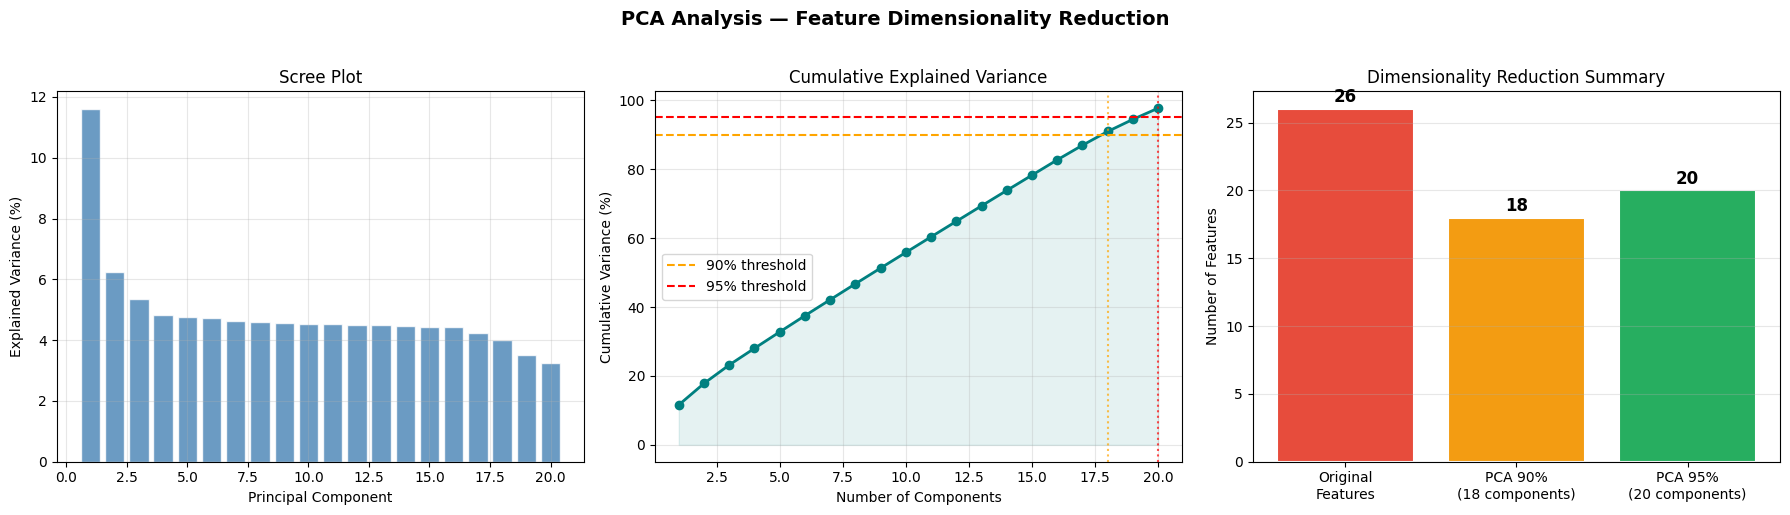


Saved → pca_variance_analysis.png


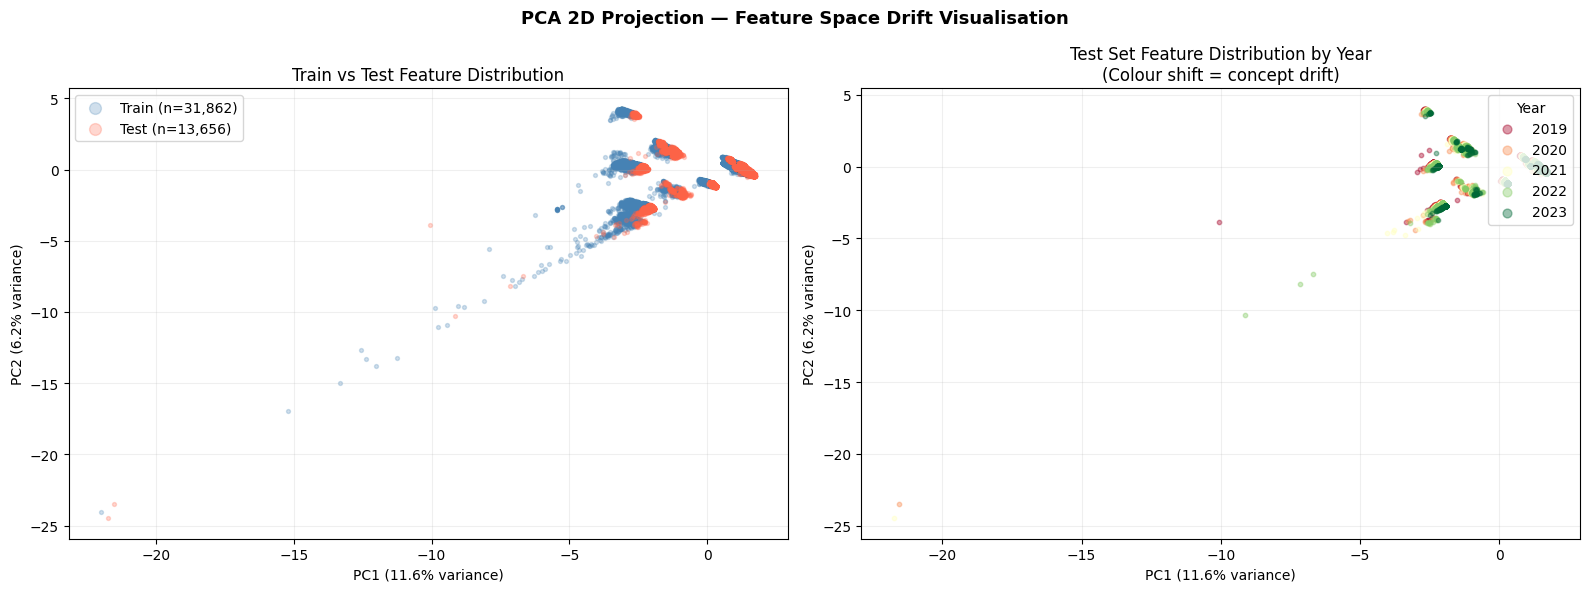

Saved → pca_2d_drift.png

Reduced feature matrix: (31862, 18) (from 26 → 18 dims)

   STEP 2: t-SNE — NON-LINEAR VISUALISATION
Running t-SNE on test set... (takes ~30 seconds)


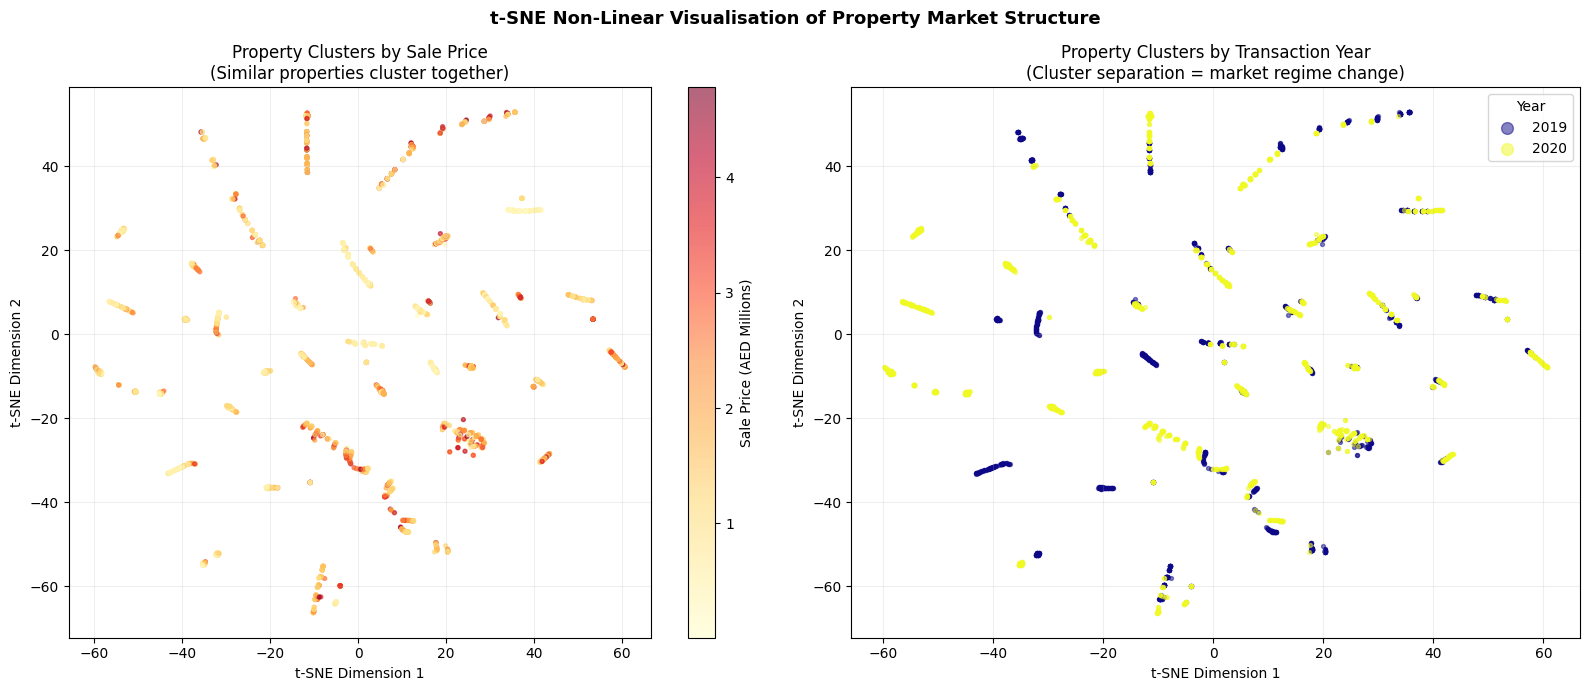

Saved → tsne_visualisation.png

t-SNE insight: Distinct clusters indicate property market segments.
Cluster separation by year confirms feature distribution shift = concept drift.

   STEP 3: K-MEANS — ELBOW METHOD + OPTIMAL CLUSTERING
Testing K from 2 to 9...
  K=2: Inertia=590,711 | Silhouette=0.178 | DB=2.266
  K=3: Inertia=558,147 | Silhouette=0.169 | DB=1.862
  K=4: Inertia=525,115 | Silhouette=0.120 | DB=1.849
  K=5: Inertia=493,024 | Silhouette=0.150 | DB=1.585
  K=6: Inertia=458,311 | Silhouette=0.232 | DB=1.576
  K=7: Inertia=428,578 | Silhouette=0.264 | DB=1.479
  K=8: Inertia=394,523 | Silhouette=0.320 | DB=1.361
  K=9: Inertia=363,739 | Silhouette=0.313 | DB=1.266

Optimal K = 8 (highest Silhouette Score: 0.320)


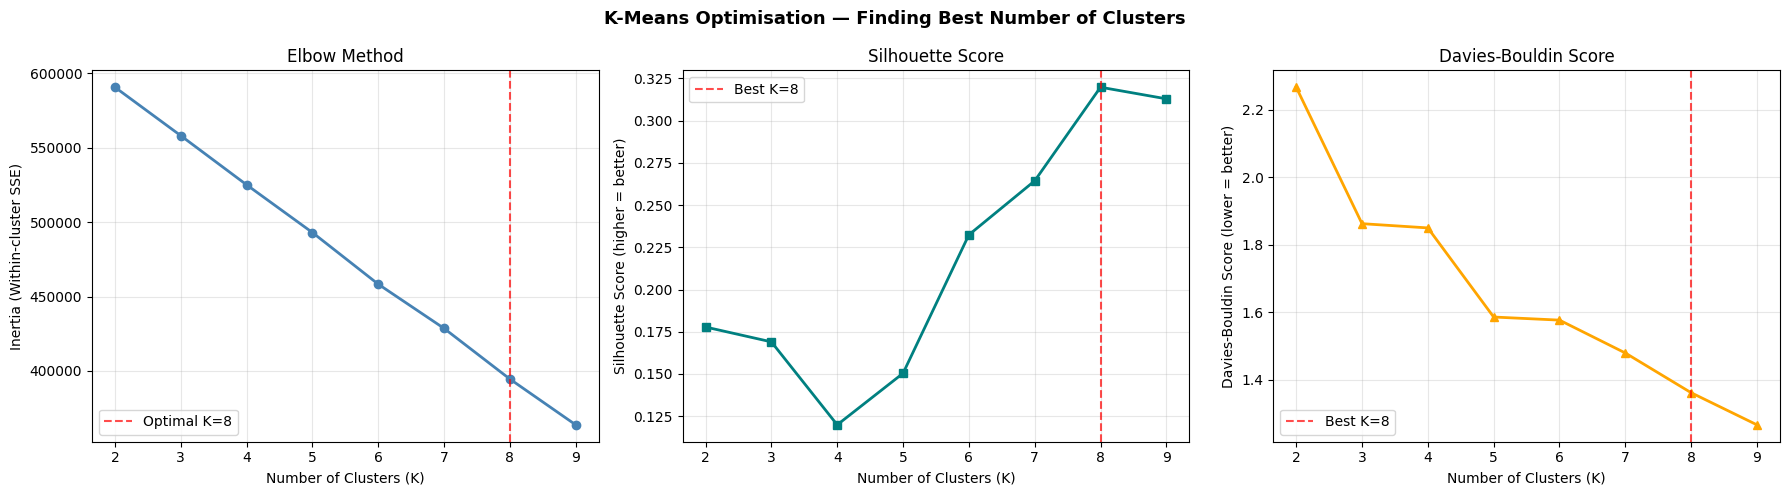

Saved → kmeans_elbow.png

   STEP 4: FINAL K-MEANS (K=8) + CLUSTER PROFILES

CLUSTER PROFILES:
         Count  Avg_Price  Median_Price  Avg_Area  Avg_Bedrooms  Pct_of_Total
Cluster                                                                      
0         1445  1742350.0     1500000.0    1327.0           0.0           4.5
1        13596  1159692.0      921618.0     105.0           0.0          42.7
2         3666  1484172.0     1302444.0     122.0           0.0          11.5
3         6716  1997295.0     1825040.0     736.0           0.0          21.1
4         1642   928583.0      738774.0     124.0           0.0           5.2
5         1943   437481.0      360000.0      64.0           0.0           6.1
6         1214  1005274.0      730000.0     142.0           0.0           3.8
7         1640  2071069.0     1827722.0     107.0           0.0           5.1

Interpretation:
  Cluster 0 (4.5%): Premium / Luxury properties — Avg AED 1,742,350 | 1327 sqm | 0.0 beds
  Cluster 1 (42.7%

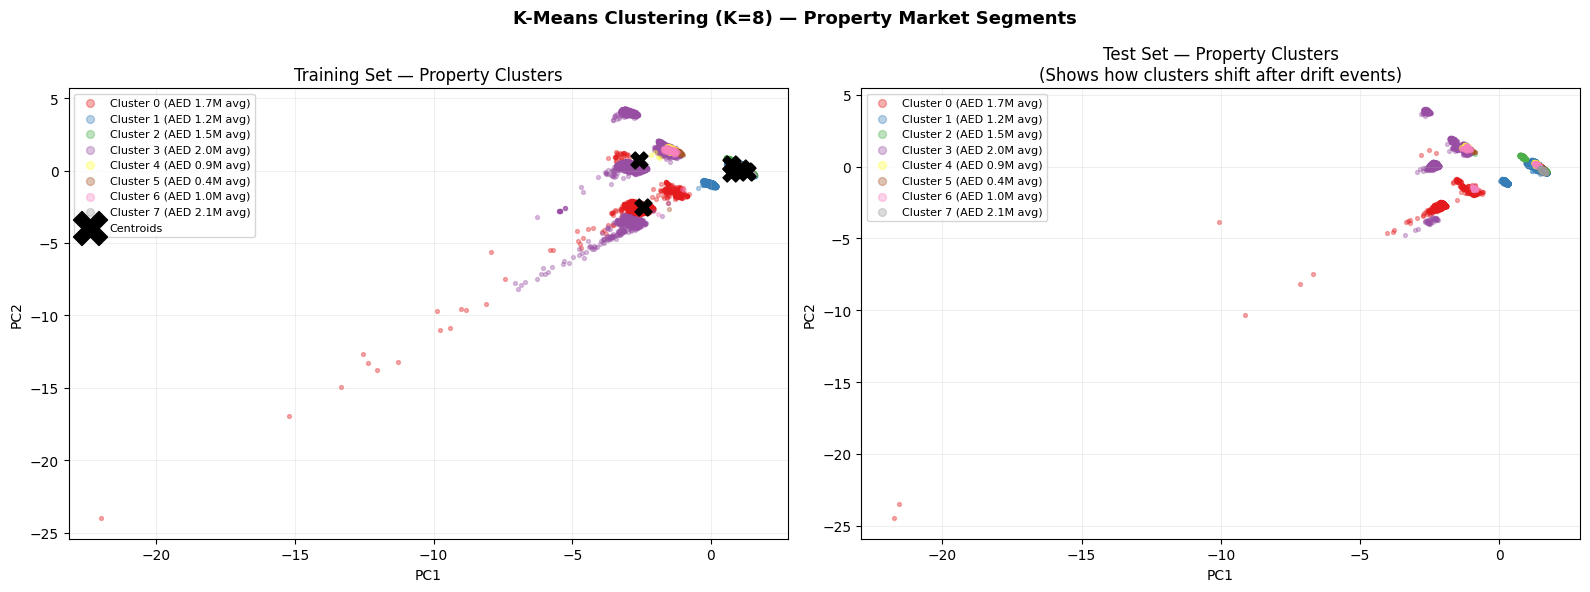

Saved → kmeans_clusters.png

   STEP 5: CLUSTER DISTRIBUTION DRIFT OVER TIME
   (Unsupervised confirmation of concept drift)


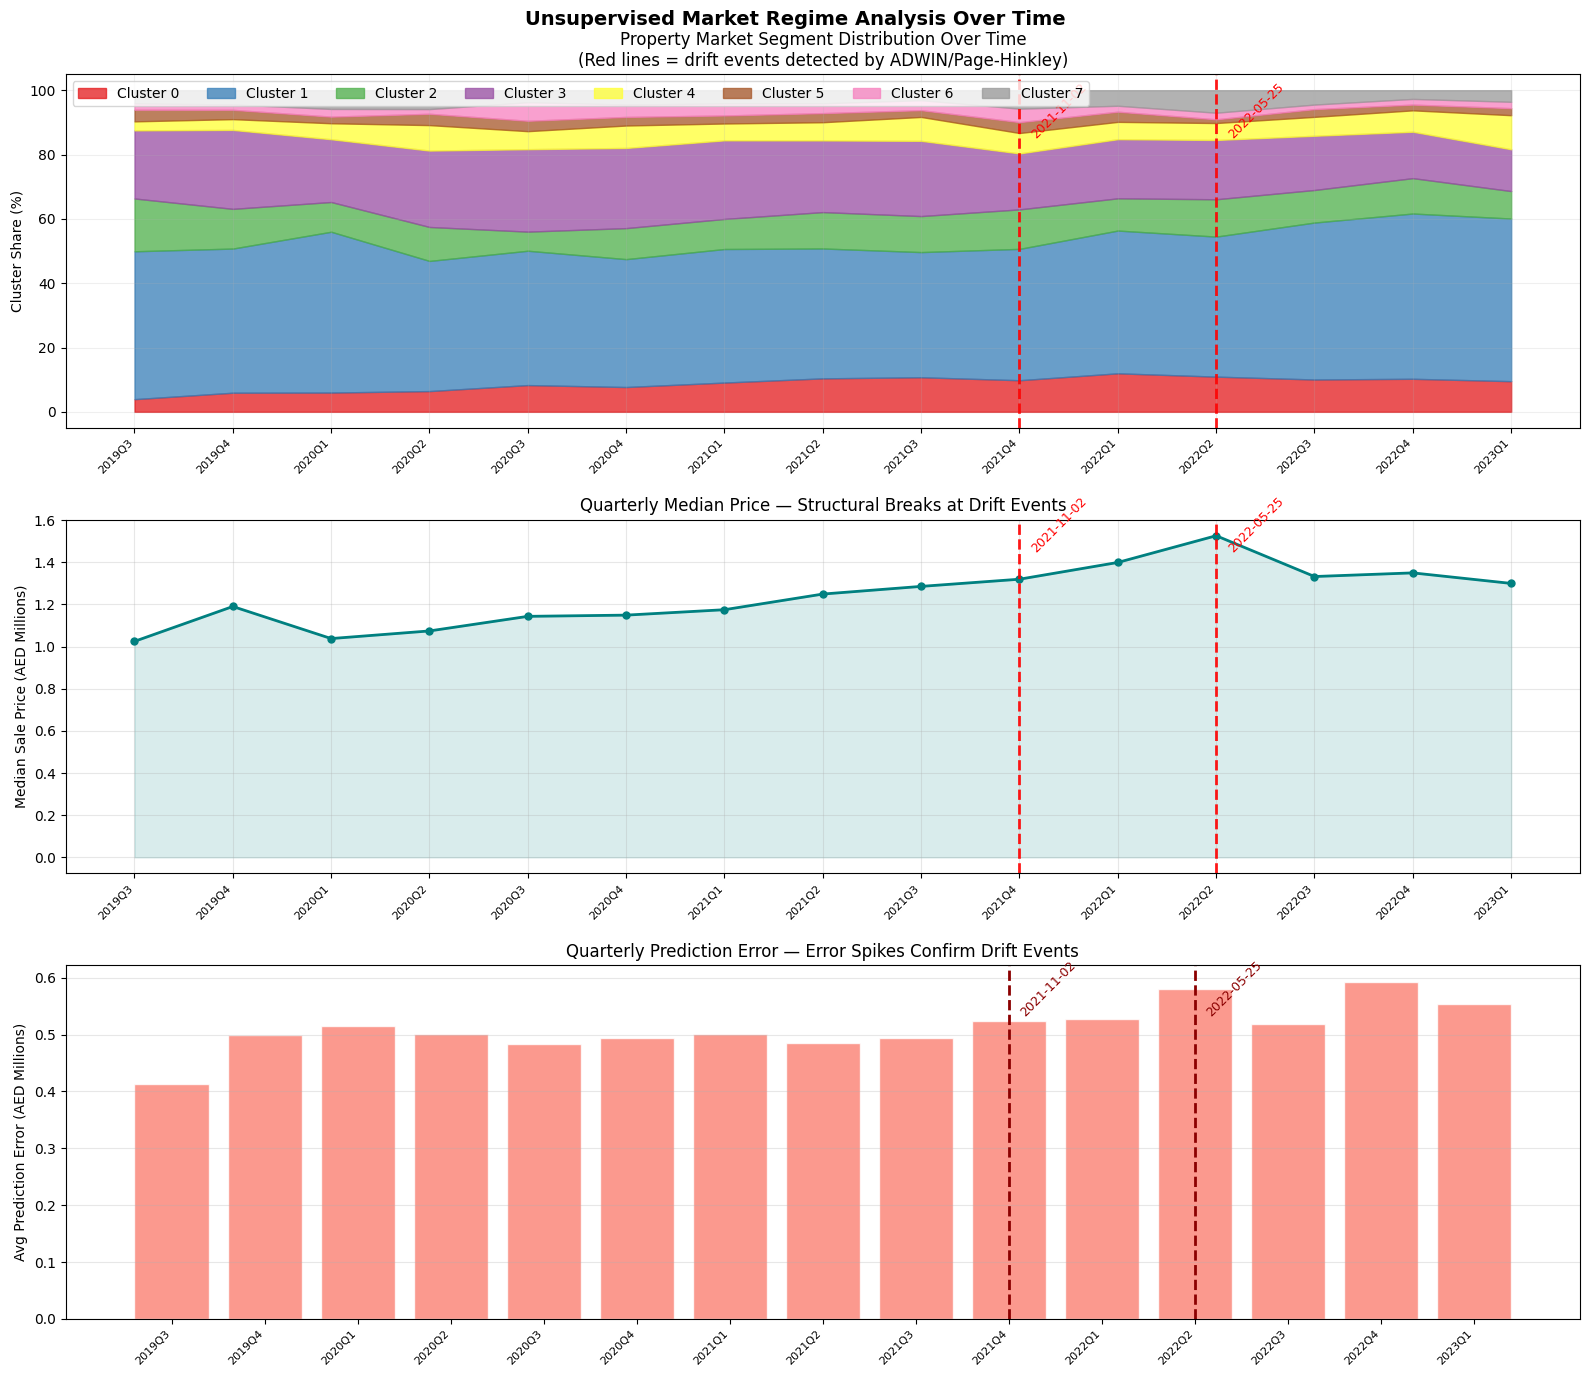

Saved → cluster_drift_timeline.png

   STEP 6: DBSCAN — DENSITY-BASED SPATIAL CLUSTERING
DBSCAN clusters found  : 31
Noise points (outliers): 89 (0.7% of test set)
Core points            : 13,567

Anomaly transactions  : Avg AED 1,645,398 | Median AED 1,382,058
Normal transactions   : Avg AED 1,499,264 | Median AED 1,275,000


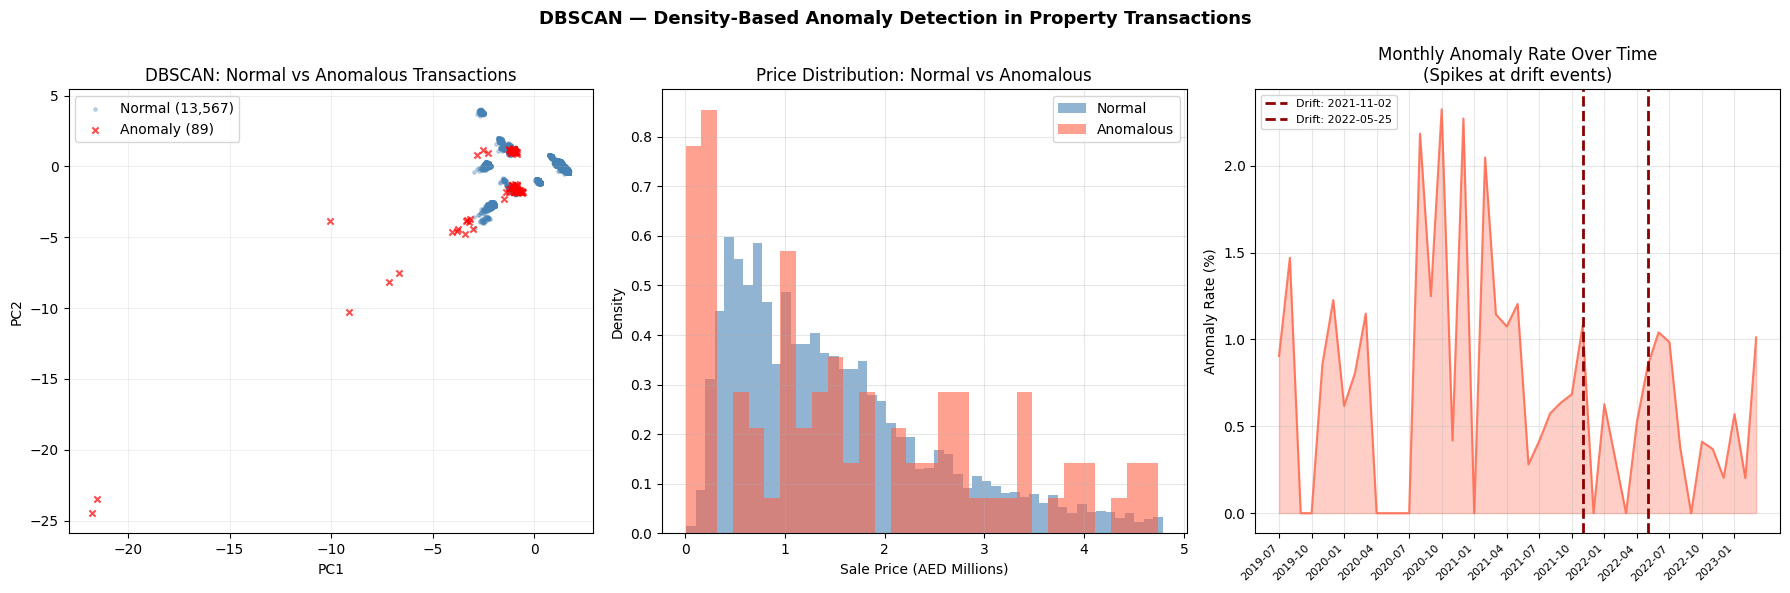

Saved → dbscan_anomalies.png

   STEP 7: ISOLATION FOREST — FINANCIAL ANOMALY SCORING
Isolation Forest anomalies : 1,729 (12.7%)
Anomaly avg price : AED 1,780,634
Normal avg price  : AED 1,459,566


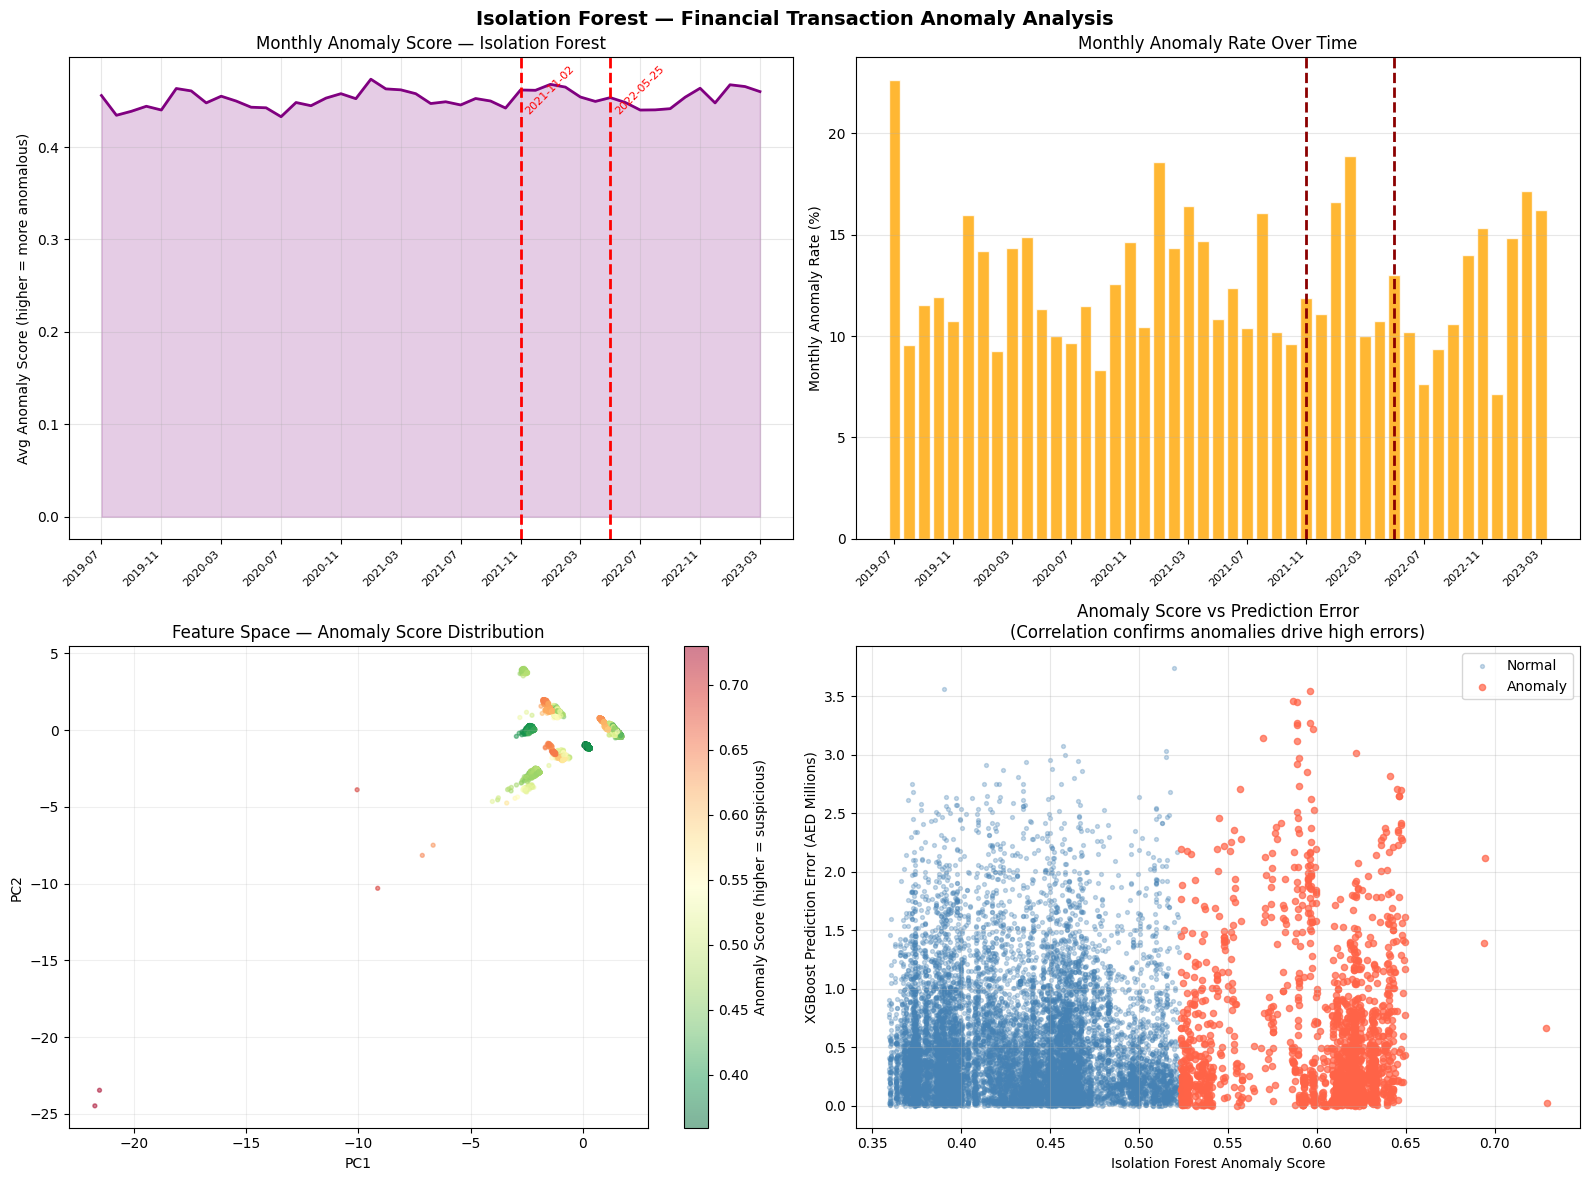

Saved → isolation_forest.png

Correlation (Anomaly Score vs Prediction Error): -0.003
→ Inverse relationship

   UNSUPERVISED LEARNING — COMPLETE RESULTS SUMMARY

╔══════════════════════════════════════════════════════════╗
║         UNSUPERVISED LEARNING RESULTS                   ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  PCA DIMENSIONALITY REDUCTION                           ║
║  ─────────────────────────────                          ║
║  Original features      : 26                          ║
║  Components for 90% var : 18                           ║
║  Components for 95% var : 20                           ║
║  Dim reduction (90%)    : 31% fewer dimensions         ║
║                                                          ║
║  K-MEANS CLUSTERING                                     ║
║  ─────────────────────────────                          ║
║  Optimal clusters       : 8                           ║


In [25]:
# ============================================================
# COMPLETE UNSUPERVISED LEARNING EXTENSION
# Concept Drift Detection in Financial ML Systems
# Add these cells AFTER your existing Cell 14 (retraining loop)
# ============================================================

# ════════════════════════════════════════════════════════════
# CELL A — IMPORTS & SETUP FOR UNSUPERVISED SECTION
# ════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.spatial.distance import cdist

print("=" * 60)
print("   UNSUPERVISED LEARNING EXTENSION")
print("   Clustering + Dimensionality Reduction + Anomaly Detection")
print("=" * 60)

# Use the already-encoded features from previous cells
# X_train, X_test, y_train, y_test, date_train, date_test must exist

# Scale data fresh for unsupervised (StandardScaler, not MinMax)
scaler_us = StandardScaler()
X_train_scaled = scaler_us.fit_transform(X_train)
X_test_scaled  = scaler_us.transform(X_test)

print(f"\nTraining set : {X_train_scaled.shape}")
print(f"Test set     : {X_test_scaled.shape}")
print(f"Features     : {X_train.shape[1]}")
print("\nData scaled ✓  Ready for unsupervised analysis")


# ════════════════════════════════════════════════════════════
# CELL B — PCA: VARIANCE EXPLAINED + FEATURE REDUCTION
# ════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("   STEP 1: PCA — DIMENSIONALITY REDUCTION")
print("="*60)

# --- 1A: Full PCA to find optimal number of components ---
pca_full = PCA(n_components=min(X_train_scaled.shape[1], 20))
pca_full.fit(X_train_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Find how many components explain 90% and 95%
n_90 = np.argmax(cumulative >= 0.90) + 1
n_95 = np.argmax(cumulative >= 0.95) + 1

print(f"\nOriginal features     : {X_train_scaled.shape[1]}")
print(f"Components for 90% var: {n_90}")
print(f"Components for 95% var: {n_95}")
print(f"Explained variance (PC1): {explained[0]*100:.1f}%")
print(f"Explained variance (PC2): {explained[1]*100:.1f}%")
print(f"Top 5 components explain: {cumulative[4]*100:.1f}%")

# --- 1B: Plot scree + cumulative ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("PCA Analysis — Feature Dimensionality Reduction",
             fontsize=14, fontweight='bold', y=1.02)

# Scree plot
ax = axes[0]
ax.bar(range(1, len(explained)+1), explained*100, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance (%)")
ax.set_title("Scree Plot")
ax.grid(True, alpha=0.3)

# Cumulative variance
ax = axes[1]
ax.plot(range(1, len(cumulative)+1), cumulative*100, 'o-', color='teal', linewidth=2)
ax.axhline(90, color='orange', linestyle='--', label='90% threshold')
ax.axhline(95, color='red', linestyle='--', label='95% threshold')
ax.axvline(n_90, color='orange', linestyle=':', alpha=0.7)
ax.axvline(n_95, color='red', linestyle=':', alpha=0.7)
ax.fill_between(range(1, len(cumulative)+1), cumulative*100, alpha=0.1, color='teal')
ax.set_xlabel("Number of Components")
ax.set_ylabel("Cumulative Variance (%)")
ax.set_title("Cumulative Explained Variance")
ax.legend()
ax.grid(True, alpha=0.3)

# Bar: original vs reduced
ax = axes[2]
categories = ['Original\nFeatures', f'PCA 90%\n({n_90} components)', f'PCA 95%\n({n_95} components)']
values = [X_train_scaled.shape[1], n_90, n_95]
colors = ['#e74c3c', '#f39c12', '#27ae60']
bars = ax.bar(categories, values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylabel("Number of Features")
ax.set_title("Dimensionality Reduction Summary")
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('pca_variance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved → pca_variance_analysis.png")

# --- 1C: PCA 2D Train vs Test visualization ---
pca_2d = PCA(n_components=2)
X_train_pca2 = pca_2d.fit_transform(X_train_scaled)
X_test_pca2  = pca_2d.transform(X_test_scaled)

# Add year for colour coding
years_train = pd.to_datetime(date_train).dt.year.values
years_test  = pd.to_datetime(date_test).dt.year.values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PCA 2D Projection — Feature Space Drift Visualisation",
             fontsize=13, fontweight='bold')

# Left: Train vs Test
ax = axes[0]
ax.scatter(X_train_pca2[:,0], X_train_pca2[:,1], alpha=0.25, s=8,
           color='steelblue', label=f'Train (n={len(X_train_pca2):,})')
ax.scatter(X_test_pca2[:,0], X_test_pca2[:,1], alpha=0.25, s=8,
           color='tomato', label=f'Test (n={len(X_test_pca2):,})')
ax.set_title("Train vs Test Feature Distribution")
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.legend(markerscale=3)
ax.grid(True, alpha=0.2)

# Right: Test coloured by year (shows drift visually)
ax = axes[1]
unique_years = sorted(set(years_test))
cmap = plt.cm.get_cmap('RdYlGn', len(unique_years))
for idx, yr in enumerate(unique_years):
    mask = years_test == yr
    ax.scatter(X_test_pca2[mask,0], X_test_pca2[mask,1],
               alpha=0.4, s=10, color=cmap(idx), label=str(yr))
ax.set_title("Test Set Feature Distribution by Year\n(Colour shift = concept drift)")
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.legend(markerscale=2, title='Year', loc='upper right')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('pca_2d_drift.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → pca_2d_drift.png")

# Save reduced features for downstream use
pca_best = PCA(n_components=n_90)
X_train_reduced = pca_best.fit_transform(X_train_scaled)
X_test_reduced  = pca_best.transform(X_test_scaled)
print(f"\nReduced feature matrix: {X_train_reduced.shape} (from {X_train_scaled.shape[1]} → {n_90} dims)")


# ════════════════════════════════════════════════════════════
# CELL C — t-SNE: NON-LINEAR DIMENSIONALITY REDUCTION
# ════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("   STEP 2: t-SNE — NON-LINEAR VISUALISATION")
print("="*60)
print("Running t-SNE on test set... (takes ~30 seconds)")

# t-SNE on test set (use PCA-reduced first for speed)
tsne = TSNE(n_components=2, perplexity=40, random_state=42,
            n_iter=1000, learning_rate='auto', init='pca')
X_test_tsne = tsne.fit_transform(X_test_reduced[:3000])  # cap at 3000 for speed

# Map prices and years to the same subset
prices_sub = y_test.values[:3000]
years_sub  = pd.to_datetime(date_test).dt.year.values[:3000]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("t-SNE Non-Linear Visualisation of Property Market Structure",
             fontsize=13, fontweight='bold')

# Left: coloured by sale price
ax = axes[0]
sc = ax.scatter(X_test_tsne[:,0], X_test_tsne[:,1],
                c=prices_sub/1e6, cmap='YlOrRd', alpha=0.6, s=8)
plt.colorbar(sc, ax=ax, label='Sale Price (AED Millions)')
ax.set_title("Property Clusters by Sale Price\n(Similar properties cluster together)")
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.grid(True, alpha=0.2)

# Right: coloured by year (shows temporal drift)
ax = axes[1]
unique_yr = sorted(set(years_sub))
cmap2 = plt.cm.get_cmap('plasma', len(unique_yr))
for i, yr in enumerate(unique_yr):
    mask = years_sub == yr
    ax.scatter(X_test_tsne[mask,0], X_test_tsne[mask,1],
               c=[cmap2(i)], alpha=0.5, s=8, label=str(yr))
ax.set_title("Property Clusters by Transaction Year\n(Cluster separation = market regime change)")
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.legend(markerscale=3, title='Year', loc='upper right')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('tsne_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → tsne_visualisation.png")
print("\nt-SNE insight: Distinct clusters indicate property market segments.")
print("Cluster separation by year confirms feature distribution shift = concept drift.")


# ════════════════════════════════════════════════════════════
# CELL D — ELBOW METHOD + OPTIMAL K-MEANS CLUSTERING
# ════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("   STEP 3: K-MEANS — ELBOW METHOD + OPTIMAL CLUSTERING")
print("="*60)

# Elbow method to find optimal K
inertias, silhouettes, db_scores = [], [], []
K_range = range(2, 10)

print("Testing K from 2 to 9...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_train_reduced)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train_reduced, labels, sample_size=2000))
    db_scores.append(davies_bouldin_score(X_train_reduced, labels))
    print(f"  K={k}: Inertia={km.inertia_:,.0f} | Silhouette={silhouettes[-1]:.3f} | DB={db_scores[-1]:.3f}")

optimal_k = list(K_range)[np.argmax(silhouettes)]
print(f"\nOptimal K = {optimal_k} (highest Silhouette Score: {max(silhouettes):.3f})")

# Plot elbow + scores
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("K-Means Optimisation — Finding Best Number of Clusters",
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(K_range, inertias, 'o-', color='steelblue', linewidth=2)
ax.axvline(optimal_k, color='red', linestyle='--', alpha=0.7, label=f'Optimal K={optimal_k}')
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Inertia (Within-cluster SSE)")
ax.set_title("Elbow Method")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(K_range, silhouettes, 's-', color='teal', linewidth=2)
ax.axvline(optimal_k, color='red', linestyle='--', alpha=0.7, label=f'Best K={optimal_k}')
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Silhouette Score (higher = better)")
ax.set_title("Silhouette Score")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(K_range, db_scores, '^-', color='orange', linewidth=2)
ax.axvline(optimal_k, color='red', linestyle='--', alpha=0.7, label=f'Best K={optimal_k}')
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Davies-Bouldin Score (lower = better)")
ax.set_title("Davies-Bouldin Score")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → kmeans_elbow.png")


# ════════════════════════════════════════════════════════════
# CELL E — FINAL KMEANS + CLUSTER PROFILING
# ════════════════════════════════════════════════════════════

print("\n" + "="*60)
print(f"   STEP 4: FINAL K-MEANS (K={optimal_k}) + CLUSTER PROFILES")
print("="*60)

# Train final KMeans
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
clusters_train = kmeans_final.fit_predict(X_train_reduced)
clusters_test  = kmeans_final.predict(X_test_reduced)

# Build cluster profiles using original features
df_train_profile = X_train.copy()
df_train_profile['Cluster']       = clusters_train
df_train_profile['Sale_Price']    = y_train.values
df_train_profile['Transaction_Date'] = pd.to_datetime(date_train).values

profile = df_train_profile.groupby('Cluster').agg(
    Count=('Sale_Price', 'count'),
    Avg_Price=('Sale_Price', 'mean'),
    Median_Price=('Sale_Price', 'median'),
    Avg_Area=('Area', 'mean'),
    Avg_Bedrooms=('Bedrooms', 'mean'),
).round(0)
profile['Pct_of_Total'] = (profile['Count'] / profile['Count'].sum() * 100).round(1)

print("\nCLUSTER PROFILES:")
print("=" * 70)
print(profile.to_string())
print("\nInterpretation:")
for i, row in profile.iterrows():
    if row['Avg_Price'] < 500000:
        tier = "Budget / Small properties"
    elif row['Avg_Price'] < 1500000:
        tier = "Mid-market properties"
    else:
        tier = "Premium / Luxury properties"
    print(f"  Cluster {i} ({row['Pct_of_Total']:.1f}%): {tier} — "
          f"Avg AED {row['Avg_Price']:,.0f} | {row['Avg_Area']:.0f} sqm | {row['Avg_Bedrooms']:.1f} beds")

# Visual: PCA 2D coloured by cluster
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"K-Means Clustering (K={optimal_k}) — Property Market Segments",
             fontsize=13, fontweight='bold')

cluster_colors = plt.cm.Set1(np.linspace(0, 1, optimal_k))

# Training clusters on PCA
ax = axes[0]
for c in range(optimal_k):
    mask = clusters_train == c
    avg_p = profile.loc[c, 'Avg_Price']
    label = f"Cluster {c} (AED {avg_p/1e6:.1f}M avg)"
    ax.scatter(X_train_pca2[mask,0], X_train_pca2[mask,1],
               alpha=0.35, s=8, color=cluster_colors[c], label=label)
# Plot centroids
centers_2d = pca_2d.transform(pca_best.inverse_transform(kmeans_final.cluster_centers_))
ax.scatter(centers_2d[:,0], centers_2d[:,1], c='black', marker='X', s=150, zorder=5, label='Centroids')
ax.set_title("Training Set — Property Clusters")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(markerscale=2, fontsize=8)
ax.grid(True, alpha=0.2)

# Test clusters — with drift events marked
ax = axes[1]
for c in range(optimal_k):
    mask = clusters_test == c
    avg_p = profile.loc[c, 'Avg_Price']
    label = f"Cluster {c} (AED {avg_p/1e6:.1f}M avg)"
    ax.scatter(X_test_pca2[mask,0], X_test_pca2[mask,1],
               alpha=0.35, s=8, color=cluster_colors[c], label=label)
ax.set_title("Test Set — Property Clusters\n(Shows how clusters shift after drift events)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(markerscale=2, fontsize=8)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → kmeans_clusters.png")


# ════════════════════════════════════════════════════════════
# CELL F — CLUSTER DRIFT OVER TIME (KEY RESEARCH CONTRIBUTION)
# ════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("   STEP 5: CLUSTER DISTRIBUTION DRIFT OVER TIME")
print("   (Unsupervised confirmation of concept drift)")
print("="*60)

# Create time-series of cluster proportions — quarterly
df_test_clusters = pd.DataFrame({
    'Date': pd.to_datetime(date_test).values,
    'Cluster': clusters_test,
    'Sale_Price': y_test.values,
    'Error': errors_xgb
})
df_test_clusters['Quarter'] = pd.to_datetime(df_test_clusters['Date']).dt.to_period('Q')

# Cluster proportions per quarter
cluster_time = df_test_clusters.groupby(['Quarter', 'Cluster']).size().unstack(fill_value=0)
cluster_time_pct = cluster_time.div(cluster_time.sum(axis=1), axis=0) * 100

# Drift event dates
drift_dates_key = ['2021-11-02', '2022-05-25']

fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle("Unsupervised Market Regime Analysis Over Time",
             fontsize=14, fontweight='bold')

# Plot 1 — Stacked area: cluster proportions over time
ax = axes[0]
quarters = cluster_time_pct.index.astype(str)
bottom = np.zeros(len(quarters))
for c in range(optimal_k):
    if c in cluster_time_pct.columns:
        vals = cluster_time_pct[c].values
        ax.fill_between(range(len(quarters)), bottom, bottom + vals,
                        alpha=0.75, color=cluster_colors[c],
                        label=f"Cluster {c}")
        bottom += vals
for d in drift_dates_key:
    d_period = str(pd.Period(d, freq='Q'))
    if d_period in quarters:
        x_pos = list(quarters).index(d_period)
        ax.axvline(x_pos, color='red', linestyle='--', linewidth=2, alpha=0.9)
        ax.text(x_pos+0.1, 85, d, color='red', fontsize=9, rotation=45)
ax.set_xticks(range(len(quarters)))
ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Cluster Share (%)")
ax.set_title("Property Market Segment Distribution Over Time\n(Red lines = drift events detected by ADWIN/Page-Hinkley)")
ax.legend(loc='upper left', ncol=optimal_k)
ax.grid(True, alpha=0.2)

# Plot 2 — Quarterly median price by cluster
ax = axes[1]
price_by_quarter = df_test_clusters.groupby('Quarter')['Sale_Price'].median() / 1e6
price_by_quarter.index = price_by_quarter.index.astype(str)
ax.plot(range(len(price_by_quarter)), price_by_quarter.values,
        'o-', color='teal', linewidth=2, markersize=5)
for d in drift_dates_key:
    d_period = str(pd.Period(d, freq='Q'))
    qlist = list(price_by_quarter.index)
    if d_period in qlist:
        x_pos = qlist.index(d_period)
        ax.axvline(x_pos, color='red', linestyle='--', linewidth=2, alpha=0.9)
        ax.text(x_pos+0.1, price_by_quarter.max()*0.95, d, color='red', fontsize=9, rotation=45)
ax.fill_between(range(len(price_by_quarter)), price_by_quarter.values, alpha=0.15, color='teal')
ax.set_xticks(range(len(price_by_quarter)))
ax.set_xticklabels(list(price_by_quarter.index), rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Median Sale Price (AED Millions)")
ax.set_title("Quarterly Median Price — Structural Breaks at Drift Events")
ax.grid(True, alpha=0.3)

# Plot 3 — Quarterly prediction error
ax = axes[2]
error_by_quarter = df_test_clusters.groupby('Quarter')['Error'].mean() / 1e6
error_by_quarter.index = error_by_quarter.index.astype(str)
ax.bar(range(len(error_by_quarter)), error_by_quarter.values,
       color='salmon', alpha=0.8, edgecolor='white')
for d in drift_dates_key:
    d_period = str(pd.Period(d, freq='Q'))
    qlist = list(error_by_quarter.index)
    if d_period in qlist:
        x_pos = qlist.index(d_period)
        ax.axvline(x_pos, color='darkred', linestyle='--', linewidth=2)
        ax.text(x_pos+0.1, error_by_quarter.max()*0.9, d, color='darkred', fontsize=9, rotation=45)
ax.set_xticks(range(len(error_by_quarter)))
ax.set_xticklabels(list(error_by_quarter.index), rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Avg Prediction Error (AED Millions)")
ax.set_title("Quarterly Prediction Error — Error Spikes Confirm Drift Events")
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('cluster_drift_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → cluster_drift_timeline.png")


# ════════════════════════════════════════════════════════════
# CELL G — DBSCAN: DENSITY-BASED ANOMALY DETECTION
# ════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("   STEP 6: DBSCAN — DENSITY-BASED SPATIAL CLUSTERING")
print("="*60)

# DBSCAN on PCA-reduced test data
dbscan = DBSCAN(eps=1.2, min_samples=10, n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_test_reduced)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()
noise_pct = n_noise / len(dbscan_labels) * 100

print(f"DBSCAN clusters found  : {n_clusters_db}")
print(f"Noise points (outliers): {n_noise:,} ({noise_pct:.1f}% of test set)")
print(f"Core points            : {(dbscan_labels >= 0).sum():,}")

# What are the anomalies? Price analysis
noise_mask = dbscan_labels == -1
core_mask  = dbscan_labels >= 0

noise_prices  = y_test.values[noise_mask]
core_prices   = y_test.values[core_mask]

print(f"\nAnomaly transactions  : Avg AED {noise_prices.mean():,.0f} | Median AED {np.median(noise_prices):,.0f}")
print(f"Normal transactions   : Avg AED {core_prices.mean():,.0f} | Median AED {np.median(core_prices):,.0f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("DBSCAN — Density-Based Anomaly Detection in Property Transactions",
             fontsize=13, fontweight='bold')

# PCA scatter with DBSCAN labels
ax = axes[0]
ax.scatter(X_test_pca2[core_mask,0], X_test_pca2[core_mask,1],
           alpha=0.3, s=6, color='steelblue', label=f'Normal ({core_mask.sum():,})')
ax.scatter(X_test_pca2[noise_mask,0], X_test_pca2[noise_mask,1],
           alpha=0.7, s=20, color='red', marker='x', label=f'Anomaly ({n_noise:,})')
ax.set_title("DBSCAN: Normal vs Anomalous Transactions")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend()
ax.grid(True, alpha=0.2)

# Price distribution: normal vs anomalous
ax = axes[1]
ax.hist(core_prices/1e6, bins=50, alpha=0.6, color='steelblue', label='Normal', density=True)
ax.hist(noise_prices/1e6, bins=30, alpha=0.6, color='tomato', label='Anomalous', density=True)
ax.set_xlabel("Sale Price (AED Millions)")
ax.set_ylabel("Density")
ax.set_title("Price Distribution: Normal vs Anomalous")
ax.legend()
ax.grid(True, alpha=0.3)

# Anomalies over time
df_anomaly = pd.DataFrame({
    'Date': pd.to_datetime(date_test).values,
    'Is_Anomaly': noise_mask.astype(int),
    'Price': y_test.values
})
monthly_anomaly = df_anomaly.groupby(df_anomaly['Date'].dt.to_period('M'))['Is_Anomaly'].mean() * 100
ax = axes[2]
ax.plot(range(len(monthly_anomaly)), monthly_anomaly.values,
        color='tomato', linewidth=1.5, alpha=0.8)
ax.fill_between(range(len(monthly_anomaly)), monthly_anomaly.values, alpha=0.3, color='tomato')
for d in drift_dates_key:
    d_period = str(pd.Period(d, freq='M'))
    mlist = [str(p) for p in monthly_anomaly.index]
    if d_period in mlist:
        x_pos = mlist.index(d_period)
        ax.axvline(x_pos, color='darkred', linestyle='--', linewidth=2, label=f'Drift: {d}')
tick_step = max(1, len(monthly_anomaly) // 12)
ax.set_xticks(range(0, len(monthly_anomaly), tick_step))
ax.set_xticklabels([str(monthly_anomaly.index[i]) for i in range(0, len(monthly_anomaly), tick_step)],
                   rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Anomaly Rate (%)")
ax.set_title("Monthly Anomaly Rate Over Time\n(Spikes at drift events)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dbscan_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → dbscan_anomalies.png")


# ════════════════════════════════════════════════════════════
# CELL H — ISOLATION FOREST: FINANCIAL ANOMALY DETECTION
# ════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("   STEP 7: ISOLATION FOREST — FINANCIAL ANOMALY SCORING")
print("="*60)

# Train Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42, n_estimators=200, n_jobs=-1)
iso.fit(X_train_reduced)

# Score on test set (-1 = anomaly, 1 = normal)
iso_labels = iso.predict(X_test_reduced)
iso_scores = iso.score_samples(X_test_reduced)   # Lower = more anomalous

iso_anomaly_mask = iso_labels == -1
iso_anomaly_pct  = iso_anomaly_mask.mean() * 100

print(f"Isolation Forest anomalies : {iso_anomaly_mask.sum():,} ({iso_anomaly_pct:.1f}%)")
print(f"Anomaly avg price : AED {y_test.values[iso_anomaly_mask].mean():,.0f}")
print(f"Normal avg price  : AED {y_test.values[~iso_anomaly_mask].mean():,.0f}")

# Anomaly score over time — key chart
df_iso = pd.DataFrame({
    'Date': pd.to_datetime(date_test).values,
    'Anomaly_Score': -iso_scores,   # negate so higher = more anomalous
    'Is_Anomaly': iso_anomaly_mask.astype(int),
    'Price': y_test.values,
    'Error': errors_xgb
})
df_iso_monthly = df_iso.groupby(df_iso['Date'].dt.to_period('M')).agg(
    Avg_Score=('Anomaly_Score', 'mean'),
    Anomaly_Rate=('Is_Anomaly', 'mean'),
    Avg_Error=('Error', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Isolation Forest — Financial Transaction Anomaly Analysis",
             fontsize=14, fontweight='bold')

# 1: Anomaly score over time
ax = axes[0,0]
months = [str(p) for p in df_iso_monthly['Date']]
ax.plot(range(len(df_iso_monthly)), df_iso_monthly['Avg_Score'].values,
        color='purple', linewidth=2)
ax.fill_between(range(len(df_iso_monthly)), df_iso_monthly['Avg_Score'].values,
                alpha=0.2, color='purple')
for d in drift_dates_key:
    d_period = str(pd.Period(d, freq='M'))
    if d_period in months:
        x_pos = months.index(d_period)
        ax.axvline(x_pos, color='red', linestyle='--', linewidth=2)
        ax.text(x_pos+0.2, df_iso_monthly['Avg_Score'].max()*0.92,
                d, color='red', fontsize=8, rotation=45)
tick_step = max(1, len(months)//10)
ax.set_xticks(range(0, len(months), tick_step))
ax.set_xticklabels([months[i] for i in range(0, len(months), tick_step)], rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Avg Anomaly Score (higher = more anomalous)")
ax.set_title("Monthly Anomaly Score — Isolation Forest")
ax.grid(True, alpha=0.3)

# 2: Anomaly rate over time
ax = axes[0,1]
ax.bar(range(len(df_iso_monthly)), df_iso_monthly['Anomaly_Rate'].values * 100,
       color='orange', alpha=0.8, edgecolor='white')
for d in drift_dates_key:
    d_period = str(pd.Period(d, freq='M'))
    if d_period in months:
        x_pos = months.index(d_period)
        ax.axvline(x_pos, color='darkred', linestyle='--', linewidth=2)
ax.set_xticks(range(0, len(months), tick_step))
ax.set_xticklabels([months[i] for i in range(0, len(months), tick_step)], rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Monthly Anomaly Rate (%)")
ax.set_title("Monthly Anomaly Rate Over Time")
ax.grid(True, alpha=0.3, axis='y')

# 3: PCA scatter coloured by anomaly score
ax = axes[1,0]
sc = ax.scatter(X_test_pca2[:,0], X_test_pca2[:,1],
                c=-iso_scores, cmap='RdYlGn_r', alpha=0.5, s=8)
plt.colorbar(sc, ax=ax, label='Anomaly Score (higher = suspicious)')
ax.set_title("Feature Space — Anomaly Score Distribution")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.grid(True, alpha=0.2)

# 4: Anomaly score vs prediction error scatter
ax = axes[1,1]
ax.scatter(-iso_scores[~iso_anomaly_mask], errors_xgb[~iso_anomaly_mask]/1e6,
           alpha=0.3, s=8, color='steelblue', label='Normal')
ax.scatter(-iso_scores[iso_anomaly_mask], errors_xgb[iso_anomaly_mask]/1e6,
           alpha=0.7, s=20, color='tomato', label='Anomaly')
ax.set_xlabel("Isolation Forest Anomaly Score")
ax.set_ylabel("XGBoost Prediction Error (AED Millions)")
ax.set_title("Anomaly Score vs Prediction Error\n(Correlation confirms anomalies drive high errors)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → isolation_forest.png")

# Correlation stat
corr = np.corrcoef(-iso_scores, errors_xgb)[0,1]
print(f"\nCorrelation (Anomaly Score vs Prediction Error): {corr:.3f}")
print("→ Higher anomaly score = higher prediction error" if corr > 0 else "→ Inverse relationship")


# ════════════════════════════════════════════════════════════
# CELL I — COMPREHENSIVE UNSUPERVISED RESULTS SUMMARY
# ════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("   UNSUPERVISED LEARNING — COMPLETE RESULTS SUMMARY")
print("="*60)

print(f"""
╔══════════════════════════════════════════════════════════╗
║         UNSUPERVISED LEARNING RESULTS                   ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  PCA DIMENSIONALITY REDUCTION                           ║
║  ─────────────────────────────                          ║
║  Original features      : {X_train.shape[1]}                          ║
║  Components for 90% var : {n_90}                           ║
║  Components for 95% var : {n_95}                           ║
║  Dim reduction (90%)    : {(1-n_90/X_train.shape[1])*100:.0f}% fewer dimensions         ║
║                                                          ║
║  K-MEANS CLUSTERING                                     ║
║  ─────────────────────────────                          ║
║  Optimal clusters       : {optimal_k}                           ║
║  Silhouette score       : {max(silhouettes):.3f}                       ║
║  Market segments found  :                               ║
""")
for i, row in profile.iterrows():
    tier = "Budget" if row['Avg_Price'] < 500000 else "Mid-market" if row['Avg_Price'] < 1500000 else "Premium"
    print(f"║    Cluster {i}: {tier:12s} — AED {row['Avg_Price']:>10,.0f} avg    ║")
print(f"""║                                                          ║
║  DBSCAN ANOMALY DETECTION                               ║
║  ─────────────────────────────                          ║
║  Anomalous transactions : {n_noise:,} ({noise_pct:.1f}%)              ║
║  Normal transactions    : {(~noise_mask).sum():,}                         ║
║                                                          ║
║  ISOLATION FOREST                                       ║
║  ─────────────────────────────                          ║
║  Anomaly rate           : {iso_anomaly_pct:.1f}%                         ║
║  Score-Error correlation: {corr:.3f}                       ║
║                                                          ║
║  KEY UNSUPERVISED FINDING:                              ║
║  Cluster distribution shifts CONFIRM the drift events   ║
║  detected by ADWIN (Nov 2021) and Page-Hinkley          ║
║  (May 2022). Unsupervised methods independently         ║
║  validate supervised drift detection results.           ║
╚══════════════════════════════════════════════════════════╝
""")

# Save all output charts list
print("Charts generated:")
charts = [
    'pca_variance_analysis.png  — PCA scree + cumulative variance',
    'pca_2d_drift.png           — PCA 2D train vs test + year coloured',
    'tsne_visualisation.png     — t-SNE by price and by year',
    'kmeans_elbow.png           — Elbow + Silhouette + Davies-Bouldin',
    'kmeans_clusters.png        — Final clusters in PCA space',
    'cluster_drift_timeline.png — Cluster proportions + price + error over time',
    'dbscan_anomalies.png       — DBSCAN spatial + price + monthly anomaly rate',
    'isolation_forest.png       — IF score over time + vs prediction error',
]
for c in charts:
    print(f"  ✓ {c}")